<a href="https://colab.research.google.com/github/jaysonDfernandez/Machine-Learning-Models/blob/main/DISEASE_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Installation

In this first step, Mask R-CNN will be installed on Google Colab in a totally automatic way, you just need to start it. Tensorflow and all necessary libraries will also be installed by the script, you won’t have to worry about a thing

In [ ]:
#Run this code to connect to your google drive account
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# installing necessary libary and Mask_RCNN to your colab.
%tensorflow_version 1.x
!pip install --upgrade h5py==2.10.0
!git clone https://github.com/pysource7/Mask_RCNN
import sys
sys.path.append("/content/Mask_RCNN/demo")
from train_mask_rcnn_demo import *
%matplotlib inline

TensorFlow 1.x selected.
     |████████████████████████████████| 2.9 MB 5.3 MB/s 
  Attempting uninstall: h5py
    Found existing installation: h5py 3.1.0
    Uninstalling h5py-3.1.0:
      Successfully uninstalled h5py-3.1.0
Cloning into 'Mask_RCNN'...
remote: Enumerating objects: 1053, done.
remote: Total 1053 (delta 0), reused 0 (delta 0), pack-reused 1053
Receiving objects: 100% (1053/1053), 125.29 MiB | 30.51 MiB/s, done.
Resolving deltas: 100% (621/621), done.
VERS 0.2


Using TensorFlow backend.


... done downloading pretrained model!


#Image Dataset

In [ ]:
#Extract Images.
#I already use the path the TANO shared drive
!unzip /content/drive/Shareddrives/TanoSecureDigiTalentInternships/Jayson/CNNModel_Leaves_Disease_Detection/DATA.zip


Archive:  /content/drive/Shareddrives/TanoSecureDigiTalentInternships/Jayson/CNNModel_Leaves_Disease_Detection/DATA.zip
  inflating: data/COCOFORMAT.json    
   creating: data/image/
  inflating: data/image/1.jpg        
  inflating: data/image/10.jpg       
  inflating: data/image/11.jpg       
  inflating: data/image/12.jpg       
  inflating: data/image/13.jpg       
  inflating: data/image/14.jpg       
  inflating: data/image/15.jpg       
  inflating: data/image/16.jpg       
  inflating: data/image/17.jpg       
  inflating: data/image/18.jpg       
  inflating: data/image/19.jpg       
  inflating: data/image/2.jpg        
  inflating: data/image/20.jpg       
  inflating: data/image/21.jpg       
  inflating: data/image/22.jpg       
  inflating: data/image/23.jpg       
  inflating: data/image/24.jpg       
  inflating: data/image/25.jpg       
  inflating: data/image/26.jpg       
  inflating: data/image/27.jpg       
  inflating: data/image/28.jpg       
  inflating: data/i

In [ ]:
#we're creating a variable here to store our image and the COCO json format
images_path = "/content/data/image"
annotation_path = "/content/data/COCOFORMAT.json"

In [ ]:
#where it loads the images into the memory of google colab, one set of images for training and one for validation
dataset_train = load = load_image_dataset(os.path.join("/content/", annotation_path), "data/image", "t")
dataset_val = load_image_dataset(os.path.join("/content/", annotation_path), "data/image", "val")
print("Validation: %d" % len(dataset_val.image_ids))

class_number = dataset_train.count_classes()
print("Classes: {}".format(class_number))

Annotation json path:  /content/data/COCOFORMAT.json
Annotation json path:  /content/data/COCOFORMAT.json
Validation: 4
Classes: 1


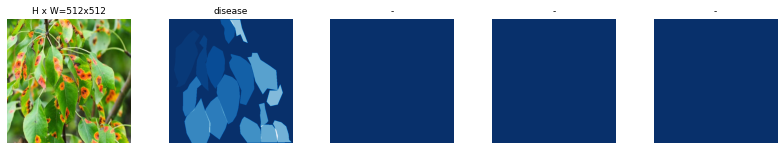

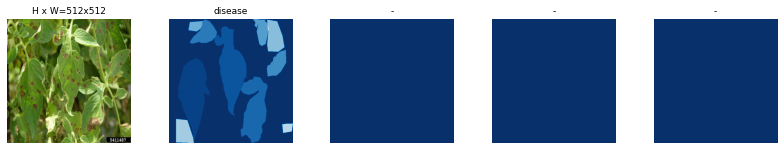

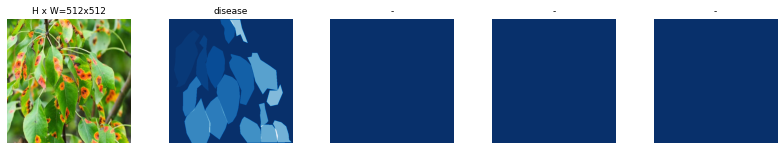

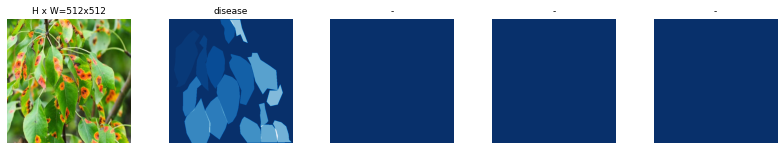

In [ ]:
#loading image samples
display_image_samples(dataset_train)

#Training

In [ ]:
#load configuration
config = CustomConfig(class_number)
#config.display()
model = load_training_model(config)

Instructions for updating:
If using Keras pass *_constraint arguments to layers.

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Instructions for updating:
box_ind is deprecated, use box_indices instead
/content/Mask_RCNN/mask_rcnn_coco.h5


In [ ]:
#start  training the model
#this operation might take a long time
train_head(model, dataset_train, dataset_train, config)


Starting at epoch 0. LR=0.001

Checkpoint Path: /content/Mask_RCNN/logs/object20211117T0533/mask_rcnn_object_{epoch:04d}.h5
Selecting layers to train
fpn_c5p5               (Conv2D)
fpn_c4p4               (Conv2D)
fpn_c3p3               (Conv2D)
fpn_c2p2               (Conv2D)
fpn_p5                 (Conv2D)
fpn_p2                 (Conv2D)
fpn_p3                 (Conv2D)
fpn_p4                 (Conv2D)
In model:  rpn_model
    rpn_conv_shared        (Conv2D)
    rpn_class_raw          (Conv2D)
    rpn_bbox_pred          (Conv2D)
mrcnn_mask_conv1       (TimeDistributed)
mrcnn_mask_bn1         (TimeDistributed)
mrcnn_mask_conv2       (TimeDistributed)
mrcnn_mask_bn2         (TimeDistributed)
mrcnn_class_conv1      (TimeDistributed)
mrcnn_class_bn1        (TimeDistributed)
mrcnn_mask_conv3       (TimeDistributed)
mrcnn_mask_bn3         (TimeDistributed)
mrcnn_class_conv2      (TimeDistributed)
mrcnn_class_bn2        (TimeDistributed)
mrcnn_mask_conv4       (TimeDistributed)
mrcnn_mask_bn

#Detection (testing the model on a random image)

In [ ]:
#Load test Model
#the latest trained model will be loaded
test_model, inference_config = load_test_model(class_number)
#the model (.h5) can be download
#it's available on the left side under /content/Mask_RCNN/logs/object/mask_rcnn_object_0005.h5 folder when you run all the blocks of code
#choose the last file which is ends in 0005



Instructions for updating:
Use `tf.cast` instead.
Loading weights from  /content/Mask_RCNN/logs/object20211117T0533/mask_rcnn_object_0005.h5
Re-starting from epoch 5


original_image           shape: (512, 512, 3)         min:    0.00000  max:  255.00000  uint8
Trained model result
Processing 1 images
image                    shape: (512, 512, 3)         min:    0.00000  max:  255.00000  uint8
molded_images            shape: (1, 512, 512, 3)      min: -123.70000  max:  151.10000  float64
image_metas              shape: (1, 14)               min:    0.00000  max:  512.00000  int64
anchors                  shape: (1, 65472, 4)         min:   -0.70849  max:    1.58325  float32
Annotation


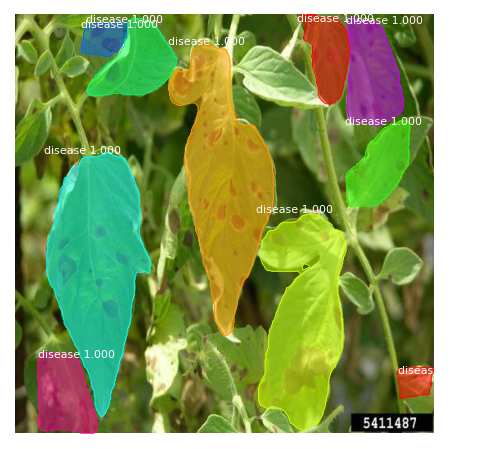

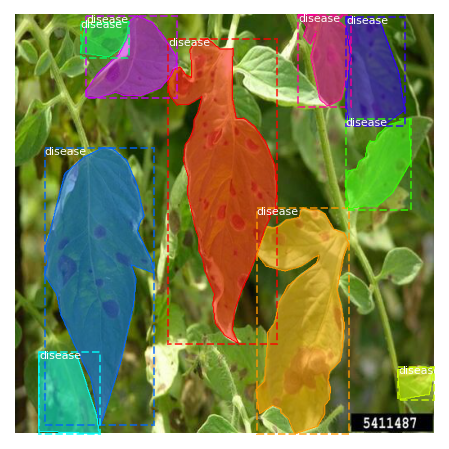

In [ ]:
#Testing on a random image
test_random_image(test_model, dataset_val, inference_config)